In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")



In [2]:

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.dtypes) #Check column names and data types

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print(df.describe()) #check basic statistics:

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [7]:
print(df['Churn'].value_counts()) #Check how many customers churned vs how many did not

No     5174
Yes    1869
Name: Churn, dtype: int64


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #Convert TotalCharges to numeric ("errors='coerce'" means values that can't be parsed to numbers become NaN inorder to expose the hidden blanks)
print(df['TotalCharges'].isnull().sum())

11


In [9]:
print(df.isnull().sum()) #Check for missing values after converting the "TotalCharges" to numeric

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
df = df.dropna(subset=['TotalCharges']) #Drop rows from df where TotalCharges is missing - those 11 rows (they are too few to matter)
print(df.shape)

(7032, 21)


In [11]:
df = df.drop(columns=['customerID']) #Drop the CustomerID column (it's just an ID, not useful for analysis)
print(df.shape)

(7032, 20)


In [12]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) #Convert the Churn column from Yes/No to 1/0.
#convertion because machine learning models only understand numbers, not text. 1 = churned, 0 = stayed
print(df['Churn'].value_counts())    #counts how many times each unique value appears.

0    5163
1    1869
Name: Churn, dtype: int64


In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Exploratory Data Analysis (EDA)

In [14]:
import matplotlib.pyplot as plt #Matplotlib, a library used for creating graphs and charts.
import seaborn as sns #Seaborn, a library built on top of Matplotlib that makes statistical graphs more attractive and easier to create.

# Set a clean visual style for all charts
sns.set(style="whitegrid")

### Overall churn rate

0    5163
1    1869
Name: Churn, dtype: int64
0    73.42
1    26.58
Name: Churn, dtype: float64


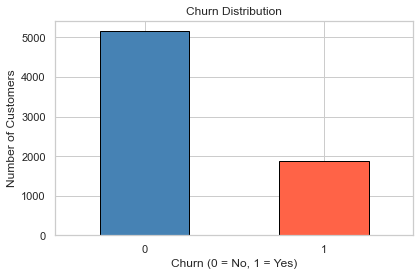

In [15]:
# See what percentage of customers actually churned
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100
# "normalize=True" makes fractions (proportions) of the total dataset.

print(churn_counts)
print(churn_percent.round(2))

# Plot it
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0) #Controls the angle of the x-axis labels to horizonal.Default rotation can sometimes tilt labels.
plt.tight_layout() #automatically adjusts spacing.
plt.show()

In [16]:
# Quick summary from chart above: ~26% of customers churned — 1 in 4 customers left

### Churn by Contract Type

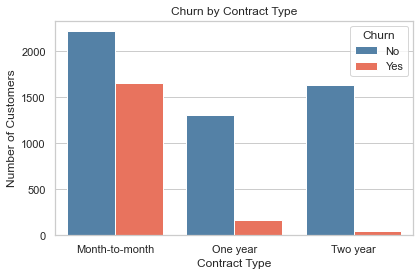

In [17]:

sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue', 'tomato']) #A count plot counts how many observations belong to each category.'hue' tells Seaborn to split each category into subgroups based on another variable.
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [18]:
# Quick summary from chart above:Month-to-month contracts have the highest churn by far suggesting that customers with longer contracts are more likely to stay with the company

### Churn by Tenure

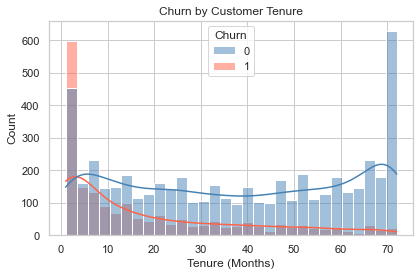

In [19]:

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue', 'tomato'], kde=True)
#KDE - Kernel Density Estimate creates a smooth curve that estimates the distribution of the data.
plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [20]:
# Quick summary from chart above: New customers (low tenure) churn the most — loyalty grows with time. Longer tenured customers tend to be more loyal

### Churn by Monthly Charges

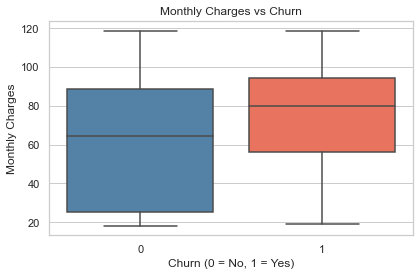

In [21]:

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue', 'tomato'])
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

In [22]:
# Quick summary from chart above:Churned customers pay higher monthly charges on average. Higher monthly charges may push customers to leave

## Prepare Data for Machine Learning

In [23]:
# Separate text columns from number columns
# Identify columns that are still text (object type)
# These need to be converted before we can train any model
categorical_cols = df.select_dtypes(include='object').columns.tolist() #.columns returns a pandas Index object. .tolist() converts it into a standard Python list, which is easier to use in later preprocessing steps.
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [24]:
#One-hot encode all text columns. Converts categorical variables into multiple binary columns, where each column represents one category and contains either 0 or 1.
# One-hot encoding creates a separate 0/1 column for each category
# e.g. Contract becomes: Contract_Month-to-month, Contract_One year, Contract_Two year
# drop_first=True removes one duplicate column per group to avoid redundancy
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) #get_dummies() is a pandas function used to perform One-Hot Encoding, converting categorical values into multiple binary (0 or 1) columns..

print(df_encoded.shape)
print(df_encoded.head())

(7032, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                               0  ...                   

In [25]:
# Split data into features (X) and target (y):
# X = everything the model learns from FEATURE
# y = what the model is trying to predict (Churn) TARGET
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape) # y is now a Series (one-dimensional), not a DataFrame.

Features shape: (7032, 30)
Target shape: (7032,)


In [26]:
# Split into training and testing sets:
from sklearn.model_selection import train_test_split

# 80% of data trains the model, 20% is kept aside to test it
# random_state=42 ensures we use same random split every time we run it, any interger number works
# test_size=0.2 ensires Keep 20% of the data for testing
# X_train, Training features, Used to teach the model
# y_train, Training labels, The correct answers during learning
# X_test, Test features, Used to evaluate the trained model
# y_test, Test labels, The correct answers for measuring performance
# X_train + y_train = the model's textbook (what it learns from).
# X_test + y_test = the model's final exam (data it has never seen before)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5625, 30)
Testing set size: (1407, 30)


In [27]:
#  Scale the numeric columns:
from sklearn.preprocessing import StandardScaler

# Scaling brings all numbers to the same range because many machine learning algorithms calculate distances between data points.
# Without this, a column like TotalCharges (thousands) would overpower tenure because of data point
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) # we need to learn the scaling parameters 'fit' then apply the scaling 'transform'
X_test = scaler.transform(X_test) # no 'fit' because the model should never learn anything from the test data.

print("Scaling complete")

Scaling complete


## Building and Evaluating the Models

In [28]:
# Train the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Logistic Regression is our baseline model — simple, fast and interpretable
# max_iter=1000 gives it enough cycles to converge on this dataset. Allowing up to 1000 attempts (iterations) to learn the best solution.
# Logistic Regression is one of the most popular algorithms for solving problems with two possible outcomes.

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression training complete")

Logistic Regression training complete


In [29]:
# Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier #An ensemble combines multiple models to make one final prediction. Random Forest is one of the most famous ensemble learning methods.

# Random Forest builds many decision trees and combines their results
# n_estimators=100 means 100 trees — good balance of speed and accuracy
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) #In Random Forest,each decision tree is called an estimator.
rf_model.fit(X_train, y_train)

print("Random Forest training complete")

Random Forest training complete


In [30]:
# Evaluate both models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# accuracy_score()    ---          Calculates overall accuracy
# classification_report()   ----   Shows Precision, Recall, F1-score and Support
# confusion_matrix()   -----       Shows correct and incorrect predictions for each class


# Generate predictions from both models on the unseen test data
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Print accuracy scores
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_preds) * 100, 2), "%")
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_preds) * 100, 2), "%")
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
Accuracy: 78.68 %
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.86      1033
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

=== Random Forest ===
Accuracy: 78.46 %
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1033
       Churn       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



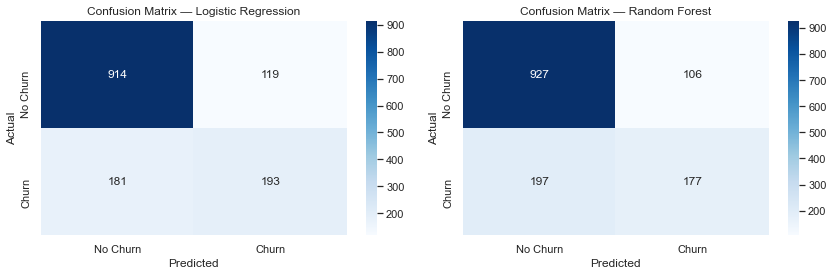

In [31]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix shows correct vs incorrect predictions broken down by class. A Confusion Matrix is a table that compares:: Actual values (the correct answers) and Predicted values (the model's answers)
for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Feature Importance

In [32]:
# Feature importance from Random Forest. Feature importance tells us how useful each feature was in helping the Random Forest make accurate predictions.

import pandas as pd

# Random Forest gives each feature an importance score
# Higher score = more influence on the churn prediction
feature_names = df_encoded.drop(columns=['Churn']).columns
importances = rf_model.feature_importances_

# Put into a dataframe and sort from highest to lowest
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_df.head(10))

                           Feature  Importance
3                     TotalCharges    0.193409
2                   MonthlyCharges    0.169758
1                           tenure    0.167572
10     InternetService_Fiber optic    0.039999
28  PaymentMethod_Electronic check    0.035016
13              OnlineSecurity_Yes    0.028905
25               Contract_Two year    0.028618
4                      gender_Male    0.026971
19                 TechSupport_Yes    0.025829
26            PaperlessBilling_Yes    0.025044


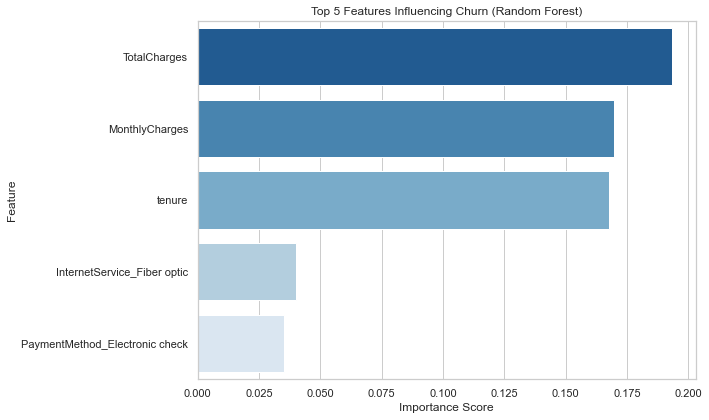

In [47]:
# Visualise the top 5 features driving churn
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df.head(5), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 5 Features Influencing Churn (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [36]:

#Feature importance tells us that TotalCharges, MonthlyCharges and Tenure are influential in churn but not whether it increases or decreases churn


## ROC Curve

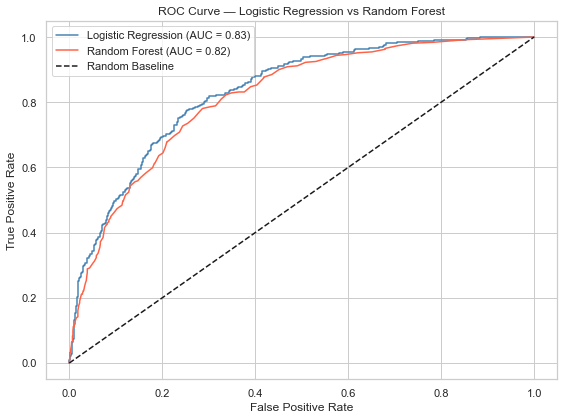

Logistic Regression AUC: 0.83
Random Forest AUC:       0.82


In [37]:
# this shows how well each model distinguishes churners from non-churners.

#Plot ROC Curve for both models. An ROC curve is a graph that shows how well a classification model distinguishes between the positive and negative classes by plotting the True Positive Rate against the False Positive Rate at different thresholds.

from sklearn.metrics import roc_curve, roc_auc_score  #ROC stands for: Receiver Operating Characteristic calculates the ROC curve points whereas roc_auc_score() Calculates the Area Under the ROC Curve (AUC)

# Get probability scores instead of hard 0/1 predictions
# The model's confidence level is more informative for the ROC curve
lr_probs = lr_model.predict_proba(X_test)[:, 1] # [:, 1] means every row but only one column which in this case is the "churn" column
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve points for each model
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs) # thresholds indicated as " _ " The thresholds are returned but not used, so _ is used as a placeholder
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Calculate AUC score — closer to 1.0 means better model
lr_auc = roc_auc_score(y_test, lr_probs) # AUC means Area Under the Curve. It summarizes the ROC curve into a single number between 0 and 1. The closer the AUC is to 1, the better the model is at separating churners from non-churners.
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot both curves on the same chart for easy comparison
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='steelblue') #plots the Logistic Regression ROC curve.
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})', color='tomato')    #plots the Random Forest ROC curve.

# The diagonal line represents a random/useless model — we want to be well above it. A useful model should have an ROC curve above this line and an AUC greater than 0.5.
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline') # diagonal line represents random guessing

plt.title('ROC Curve — Logistic Regression vs Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {lr_auc:.2f}")
print(f"Random Forest AUC:       {rf_auc:.2f}")


In [38]:
# Quick summary from chart above
# AUC of 0.83 (LR) and 0.82 (RF) — both models are well above the 0.5 baseline (random guessing), meaning they genuinely learned patterns from the data

## Export Results for Your Report & Dashboard

In [67]:
# Save the cleaned dataset for reference in your report
df.to_csv("telco_churn_cleaned.csv", index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


In [68]:
# Save top 10 features — useful for  dashboard and report
feature_df.head(10).to_csv("feature_importance.csv", index=False)
print("Feature importance saved")

Feature importance saved


In [69]:
#Export predictions vs actual values:
# Save model predictions alongside actual values for dashboard use
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'LR_Predicted': lr_preds,
    'RF_Predicted': rf_preds
})
results_df.to_csv("model_predictions.csv", index=False)
print("Predictions saved")

Predictions saved


In [70]:
#Export churn summary by contract type
# This will be useful for your Power BI / dashboard charts
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate']
contract_churn['Churn_Rate'] = (contract_churn['Churn_Rate'] * 100).round(2)
contract_churn.to_csv("churn_by_contract.csv", index=False)
print("Contract churn summary saved")
print(contract_churn)

Contract churn summary saved
         Contract  Churn_Rate
0  Month-to-month       42.71
1        One year       11.28
2        Two year        2.85
